In [127]:
%pylab inline

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


/home/emmabob/miniconda3/envs/tudat-space/lib/python3.10/site-packages/IPython/core/magics/pylab.py:166: UserWarning: pylab import has clobbered these variables: ['text']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


In [2]:
from tudatpy.interface import spice
from tudatpy.dynamics import environment_setup, parameters_setup, propagation_setup
from tudatpy import estimation
from tudatpy.estimation import observable_models_setup, estimation_analysis
from tudatpy.constants import GRAVITATIONAL_CONSTANT
from tudatpy.astro.frame_conversion import inertial_to_rsw_rotation_matrix
import matplotlib.gridspec as gridspec
from tudatpy.data.mpc import BatchMPC
from tudatpy.data.horizons import HorizonsQuery
from tudatpy.data.sbdb import SBDBquery

from tudatpy.estimation import observable_models, observations_setup, observations

# other useful modules
import numpy as np
import datetime
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D
from tudatpy.astro import time_representation
from tudatpy.astro.time_representation import DateTime
from astropy.table import Table
from tudatpy.astro import element_conversion    # for TU3 initial state

# additional things for the asteroids
from tudatpy import constants
import os           # for the extraction of asteroid kernels
from astroquery.jplhorizons import Horizons     # for extracting Cartesian coordinates

# SPICE KERNELS
spice.load_standard_kernels()

# bdir = '/home/balbinot/Bachelor_Project_Emma/'

In [ ]:
# Defining some constants

# Target 1998 TU3 (66146)
target_mpc_code = "66146"

# 10 years
observations_start = datetime.datetime(2000, 1, 1)      # 1st Jan 2015 at 12:00
observations_end = datetime.datetime(2026, 1, 1)

# number of iterations for our estimation
# Change this depending on how long you want the convergence to run
number_of_pod_iterations = 5

# timestep of 24 hours for our estimation
timestep_global = 24 * 3600.0

# 2 month time buffer used to avoid interpolation errors:
time_buffer = 2 * 31 * 86400.0

# Define the frame origin and orientation
# This is useful for the large functions at the end
# However, I still define the frame orientation before then for my bodies
global_frame_origin = "SSB"
global_frame_orientation = "J2000"

In [87]:
target_sbdb = SBDBquery(target_mpc_code)

mpc_codes = [target_mpc_code]  # the BatchMPC interface requires a list.
target_spkid = target_sbdb.codes_300_spkid  # the ID used by Tudat
obj = target_sbdb.query["object"]

# The ID used by Tudat (biggest asteroids have shortname, but smaller don't)
target_name = (
    obj.get("shortname") or
    obj.get("fullname") or
    obj.get("des")
)  

print(f"SPK ID for {target_name} is: {target_spkid}")

SPK ID for 66146 (1998 TU3) is: 2066146


In [88]:
setup_names = ["LVL1 Accelerations", "LVL2 Accelerations", "LVL3 Accelerations"]

accel_levels = [1, 2, 3]
use_sat_data =    [True, True, True]
use_catalog_cor = [True, True, True]
use_weighting =   [True, True, True]

satellites_names = ["WISE"]
satellites_MPC_codes = ["C51"]  # C51 is the observatory code MPC uses for WISE
satellites_Horizons_codes = [
    "-163"
]  # -163 is the query ID for WISE in Horizons see explanation below.

# Consider trying out different combinations of satellites.
# Note that you must change the dates to use TESS as it launched in April 2018
# satellites_names = ["WISE", "TESS"]
# satellites_MPC_codes = ["C51", "C57"]
# satellites_Horizons_codes = ["-163", "-95"]

In [89]:
# Retrieving the observations
batch = BatchMPC()
batch.get_observations(mpc_codes)
batch.filter(
    epoch_start = observations_start,
    epoch_end = observations_end,
)
print(batch.summary())


   Batch Summary:
1. Batch includes 1 minor planets:
   ['66146']
2. Batch includes 148 observations, including 20 observations from space telescopes
3. The observations range from 2010-07-09 02:13:04.224004 to 2010-11-25 01:44:23.136014
   In seconds TDB since J2000: 331913650.4079133 to 343921529.3189183
   In Julian Days: 2455386.59241 to 2455525.57249
4. The batch contains observations from 8 observatories, including 1 space telescopes

None


/home/emmabob/miniconda3/envs/tudat-space/lib/python3.10/site-packages/tudatpy/data/mpc/mpc.py:866: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['66146' '66146' '66146' ... '66146' '66146' '66146']' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  obs.loc[:, "number"] = obs.number.astype(str)


Text(0.5, 1.0, 'Visualize the observations')

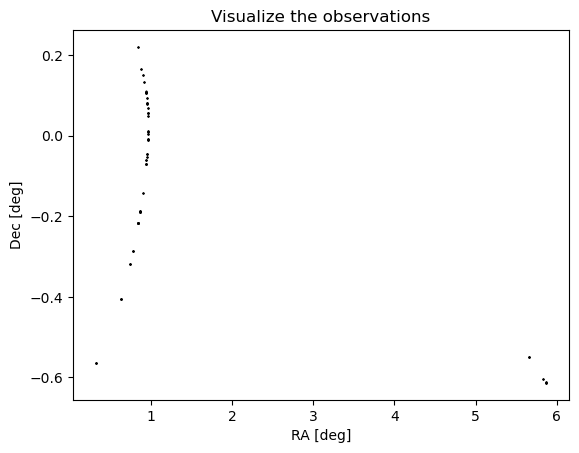

In [90]:
plot(batch.table['RA'], batch.table['DEC'], 'k.', ms=1)
xlabel('RA [deg]')
ylabel('Dec [deg]')
title("Visualize the observations")

In [91]:
from astropy import coordinates as coords

ccc = coords.SkyCoord(ra=batch.table['RA'], dec=batch.table['DEC'], unit='deg')

In [92]:
ttt = ccc.transform_to('geocentricmeanecliptic')

In [93]:
ttt

<SkyCoord (GeocentricMeanEcliptic: equinox=J2000.000, obstime=J2000.000): (lon, lat, distance) in (deg, deg, )
    [(0.8634869 , -0.13482518, 1.), (0.86349052, -0.1348278 , 1.),
     (0.86348631, -0.1348302 , 1.), (0.87507567, -0.19885926, 1.),
     (0.87507805, -0.19886293, 1.), (0.87508098, -0.19886896, 1.),
     (0.88624887, -0.22120054, 1.), (0.88624771, -0.22120321, 1.),
     (0.88625333, -0.2212067 , 1.), (0.89708889, -0.2451846 , 1.),
     (0.89708945, -0.24518696, 1.), (0.89709183, -0.24519063, 1.),
     (0.90604143, -0.27340407, 1.), (0.90617556, -0.27399067, 1.),
     (0.90630777, -0.27458172, 1.), (0.90643611, -0.27518167, 1.),
     (0.9064951 , -0.27546618, 1.), (0.90656164, -0.27576983, 1.),
     (0.90662344, -0.27606613, 1.), (0.90674512, -0.27666318, 1.),
     (0.90680217, -0.27695215, 1.), (0.90686205, -0.2772529 , 1.),
     (0.90698179, -0.2778544 , 1.), (0.90709872, -0.27844412, 1.),
     (0.90720986, -0.27904718, 1.), (0.90917695, -0.293421  , 1.),
     (0.90917483, 

(-2.0, 10.0)

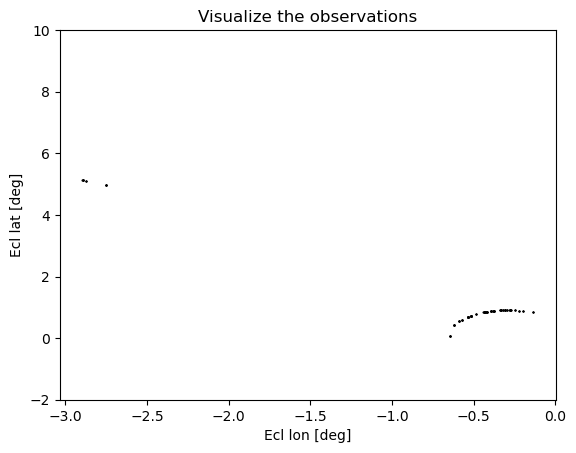

In [94]:
plot(ttt.lat, ttt.lon, 'k.', ms=1)
xlabel('Ecl lon [deg]')
ylabel('Ecl lat [deg]')
title("Visualize the observations")
ylim(-2,10)
# Almost in the ecliptic plane

In [95]:
# Retrieve the first and final observation epochs and add the buffer
# Manual buffer instead of a random one
epoch_start_nobuffer = DateTime.from_epoch(batch.epoch_start)
epoch_end_nobuffer =  DateTime.from_epoch(batch.epoch_end)

print(f"Epoch Start (no buffer): {epoch_start_nobuffer.to_epoch()}")
print(f"Epoch End (no buffer): {epoch_end_nobuffer.to_epoch()}")
print("--------------------------------------------------")
print(f"Epoch Start (no buffer): {epoch_start_nobuffer}")
print(f"Epoch End (no buffer): {epoch_end_nobuffer}")
print("--------------------------------------------------")


# This samples the cartesian state at 500 points over the observation time:
times_get_eph = np.linspace(epoch_start_nobuffer.to_epoch(), epoch_end_nobuffer.to_epoch(), 500)
epoch_start_buffer = epoch_start_nobuffer.to_epoch() - time_buffer
epoch_end_buffer = epoch_end_nobuffer.to_epoch() + time_buffer

print(f"Epoch Start (buffer): {epoch_start_buffer}")
print(f"Epoch End (buffer): {epoch_end_buffer}")
print("Summary of space telescopes in batch:")
print(batch.observatories_table(only_space_telescopes=True))

Epoch Start (no buffer): 331913650.4079133
Epoch End (no buffer): 343921529.3189183
--------------------------------------------------
Epoch Start (no buffer): 2010-07-09 02:14:10.407913327217102
Epoch End (no buffer): 2010-11-25 01:45:29.318918287754059
--------------------------------------------------
Epoch Start (buffer): 326556850.4079133
Epoch End (buffer): 349278329.3189183
Summary of space telescopes in batch:
     Code  Name  count
1239  C51  WISE   20.0


In [96]:
# Set up the environment

# The lagrer bodies exist inside of SPICE and are well-defined
larger_bodies_to_create = [
    "Sun",
    "Earth",
    "Mercury",
    "Venus",
    "Mars",
    "Jupiter",
    "Saturn",
    "Uranus",
    "Neptune"
]

# The 21 smaller bodies do not exist inside of SPICE and therefore their mu has to be manually added
# Create a dictionary to store the names, ID numbers and mu (GM in km3/s2) of the asteroids 

# Will check later if I need to add e.g. radius, radiation or time of orbit around the Sun etc.

smaller_bodies = {
    "Ceres": [1, 62.10], 
    "Pallas": [2, 13.73],
    "Juno": [3, 1.61],
    "Vesta": [4, 17.38],
    "Hebe": [6, 0.89],
    "Iris": [7, 0.73],
    "Flora": [8, 0.27],
    "Metis": [9, 0.44],
    "Hygiea": [10, 5.97],
    "Irene": [14, 0.25],
    "Eunomia": [15, 1.88],
    "Psyche": [16, 1.65],
    "Fortuna": [19, 0.42],
    "Thalia": [23, 0.15],
    "Amphitrite": [29, 0.98],
    "Daphne": [41, 0.56],
    "Europa": [52, 1.48],
    "Bamberga": [324, 0.71],
    "Davida": [511, 1.14],
    "Herculina": [532, 0.66],
    "Interamnia": [704, 2.65]
}



In [97]:
# Many of the asteroids do not exist in the SPICE kernel
# Therefore I'm now adding them by downloading them in SPK files from the JPL Horizon website
# Then I will extract them with load_kernel

# ---------------------------------------------------------
# The path to the folder where the .bsp files are located
kernel_directory = "/home/emmabob/Bachelor_Project/asteroid_kernels/" 
# kernel_directory = "/home/balbinot/Bachelor_Project_Emma/asteroid_kernels/" 
print("Number of kernels:", spice.get_total_count_of_kernels_loaded())

# Loop through the dictionary and load the corresponding .bsp file
for i, (name, data) in enumerate(smaller_bodies.items(), start=1):
    
    # Calculate the NAIF ID from the data list
    # E.g. Juno has 20000003 (ID: 3)
    ast_id = data[0]
    naif_id = 20000000 + ast_id
    
    # Then extract the ephemeris for each asteroid
    kernel_path = os.path.join(kernel_directory, f"{naif_id}.bsp")
    if os.path.exists(kernel_path):
        spice.load_kernel(kernel_path)
        print(f"{i}.Successfully loaded the kernel for {name} using file: {naif_id}.bsp")
    else:
        print(f"WARNING: Could not find {name}. Its kernel was not found at {kernel_path}. Make sure the file exists.")

Number of kernels: 57
1.Successfully loaded the kernel for Ceres using file: 20000001.bsp
2.Successfully loaded the kernel for Pallas using file: 20000002.bsp
3.Successfully loaded the kernel for Juno using file: 20000003.bsp
4.Successfully loaded the kernel for Vesta using file: 20000004.bsp
5.Successfully loaded the kernel for Hebe using file: 20000006.bsp
6.Successfully loaded the kernel for Iris using file: 20000007.bsp
7.Successfully loaded the kernel for Flora using file: 20000008.bsp
8.Successfully loaded the kernel for Metis using file: 20000009.bsp
9.Successfully loaded the kernel for Hygiea using file: 20000010.bsp
10.Successfully loaded the kernel for Irene using file: 20000014.bsp
11.Successfully loaded the kernel for Eunomia using file: 20000015.bsp
12.Successfully loaded the kernel for Psyche using file: 20000016.bsp
13.Successfully loaded the kernel for Fortuna using file: 20000019.bsp
14.Successfully loaded the kernel for Thalia using file: 20000023.bsp
15.Successfully 

In [98]:
print("Number of kernels:", spice.get_total_count_of_kernels_loaded())

Number of kernels: 78


In [99]:
# Extract only the asteroids' names 
# This is so that the list of all bodies can be created
smaller_bodies_list = list(smaller_bodies.keys())

asteroid_name = "66146" # This is TU3

# Combine all bodies into one large list
bodies_to_create = larger_bodies_to_create + smaller_bodies_list + [asteroid_name]
bodies_to_propagate = asteroid_name     # I only propagate TU3, I pull the other values from pre-existing ephemeris

# ----------------------------
# Create bodies in simulation.
# Pull on the data already known for the larger bodies
body_settings = environment_setup.get_default_body_settings(
    bodies = larger_bodies_to_create, 
    base_frame_origin = 'SSB',                   # Correct as initial conditions from JPL are in SSB
    base_frame_orientation = 'J2000')       # Intiial conditions from JPL are in J2000

# Add a buffer time
buffer_time = 5 * constants.JULIAN_DAY

# A for loop to extract and add settings for the 21 massive asteroids from JPL Horizon
for i, (name, data) in enumerate(smaller_bodies.items(), start=1):

    # Extract asteroid properties
    ast_id = data[0]
    ast_mu = data[1] * 1e9  # Convert km^3/s^2 to m^3/s^2 (SI-units); reduced mass

    # Calculate the SPICE NAIF ID (2000000 + minor planet number) again
    naif_id = 20000000 + ast_id

    try:
        
        # To fix Tudat finding the data:
        naif_id_str = str(2000000 + ast_id)

        # Instead try extracting the ephemeris from SPICE (w. direct_spice) 
        DIRECT_ephemeris_settings_ast = environment_setup.ephemeris.direct_spice(
            frame_origin = 'SSB',                    # The SPK files were w.r.t the Sun
            frame_orientation = 'J2000',        # tells Tudat the asteroids' coordinates are wrt ECLIPJ2000 
            body_name_to_use = naif_id_str)

        # Create empty slots, then insert the asteroids
        body_settings.add_empty_settings(name)
        # Assign ephemeris
        body_settings.get(name).ephemeris_settings = DIRECT_ephemeris_settings_ast

        # Assign gravity field (w. the central function that manually adds the mu)
        body_settings.get(name).gravity_field_settings = (
            environment_setup.gravity_field.central(ast_mu)
        )

        print(f" {i}. Successfully configured {name} (ID: {ast_id} / NAIF: {naif_id})")

    except Exception as e:
        print(f"Could not fetch data for {name}: {e}")

# Manually add empty settings for TU3
body_settings.add_empty_settings(asteroid_name)

 1. Successfully configured Ceres (ID: 1 / NAIF: 20000001)
 2. Successfully configured Pallas (ID: 2 / NAIF: 20000002)
 3. Successfully configured Juno (ID: 3 / NAIF: 20000003)
 4. Successfully configured Vesta (ID: 4 / NAIF: 20000004)
 5. Successfully configured Hebe (ID: 6 / NAIF: 20000006)
 6. Successfully configured Iris (ID: 7 / NAIF: 20000007)
 7. Successfully configured Flora (ID: 8 / NAIF: 20000008)
 8. Successfully configured Metis (ID: 9 / NAIF: 20000009)
 9. Successfully configured Hygiea (ID: 10 / NAIF: 20000010)
 10. Successfully configured Irene (ID: 14 / NAIF: 20000014)
 11. Successfully configured Eunomia (ID: 15 / NAIF: 20000015)
 12. Successfully configured Psyche (ID: 16 / NAIF: 20000016)
 13. Successfully configured Fortuna (ID: 19 / NAIF: 20000019)
 14. Successfully configured Thalia (ID: 23 / NAIF: 20000023)
 15. Successfully configured Amphitrite (ID: 29 / NAIF: 20000029)
 16. Successfully configured Daphne (ID: 41 / NAIF: 20000041)
 17. Successfully configured E

In [100]:
# Extract the ephemeris for the target asteroids for the initial guess

kernel_directory_TU3 = "/home/emmabob/Bachelor_Project/asteroid_kernels/9_asteroids_SPK" 
# kernel_directory_TU3 = f"{bdir}/asteroid_kernels/9_asteroids_SPK" 

# Calculate the NAIF ID from the data list
# E.g. Juno has 20000003 (ID: 3)
ast_id_TU3 = 66146
naif_id_TU3 = 20000000 + ast_id_TU3
print(naif_id_TU3)
    
# Then extract the ephemeris for each asteroid
kernel_path_TU3 = os.path.join(kernel_directory_TU3, f"{naif_id_TU3}.bsp")
if os.path.exists(kernel_path_TU3):
    spice.load_kernel(kernel_path_TU3)
    print(f"{i+1}.Successfully loaded the kernel for 1998-TU3 using file: {naif_id_TU3}.bsp")
else:
    print(f"WARNING: Could not find 1998_TU3. Its kernel was not found at {kernel_path_TU3}. Make sure the file exists.")



20066146
22.Successfully loaded the kernel for 1998-TU3 using file: 20066146.bsp


In [101]:
# initial_guess_spice = spice.get_body_cartesian_state_at_epoch(
#     "20066146",
#     "SSB",
#     "J2000",
#     "NONE",
#     epoch_start_buffer
# )

obj = HorizonsQuery(
    query_id="66146",
    location="@SSB",
    epoch_list=[epoch_start_buffer],
)

initial_guess = obj.cartesian(frame_orientation='J2000',
              aberations='geometric')

initial_guess = initial_guess[0][1:]

In [102]:
# initial_guess - initial_guess_spice

In [103]:
times_get_eph = np.linspace(epoch_start_nobuffer.to_epoch(), epoch_end_nobuffer.to_epoch(), 500)
epoch_start_buffer = epoch_start_nobuffer.to_epoch() - time_buffer
epoch_end_buffer = epoch_end_nobuffer.to_epoch() + time_buffer

print("The initial state for 1998-TU3 (20066146) in SPICE at epoch_start (w a buffer):")
print(epoch_start_buffer, initial_guess)

The initial state for 1998-TU3 (20066146) in SPICE at epoch_start (w a buffer):
326556850.4079133 [-5.41285112e+10  3.49199314e+10  1.96729458e+10 -2.03624479e+04
 -4.63936948e+04 -1.69751788e+04]


In [104]:
# Retrieve the asteroid's body name from BatchMPC 
# I am unsure whether this command literally extracts all of the batch..?
# Because this is the first time MPC_objects is mentioned...?
bodies_to_propagate = batch.MPC_objects
# bodies_to_propagate = ["1998-TU3"]
# bodies_to_propagate = ["66146"]


# Set its centre to enable its propapgation
# Uhuh, not the Sun...?
# central_bodies = ["SSB"] * len(batch.MPC_objects)
# print(central_bodies)
central_bodies = ["SSB"]

print(bodies_to_propagate)

['66146']


In [105]:
# Create the accelerations
# ^insert mini boss music here^

# Recall:
# Level 1: Sun, 8 planets and GR
# Level 2: Sun, 8 planets, 21 asteroids and GR
# Level 3: Sun, 8 planets, 21 asteroids, GR, J2 and Yarkovsky

In [106]:
# LVL1

acceleration_LVL1 = {
    "Sun": [
        # The Sun's gravity 
        propagation_setup.acceleration.point_mass_gravity(), 
        # Activating General Relativity (exerted by the Sun / the largest body)
        # Sufficient to use the Schwarzschild Correction
        propagation_setup.acceleration.relativistic_correction(use_schwarzschild=True), # General Relativity
    ],
    "Mercury": [propagation_setup.acceleration.point_mass_gravity()],
    "Venus": [propagation_setup.acceleration.point_mass_gravity()],
    "Earth": [propagation_setup.acceleration.point_mass_gravity()],
    "Mars": [propagation_setup.acceleration.point_mass_gravity()],
    "Jupiter": [propagation_setup.acceleration.point_mass_gravity()],
    "Saturn": [propagation_setup.acceleration.point_mass_gravity()],
    "Uranus": [propagation_setup.acceleration.point_mass_gravity()],
    "Neptune": [propagation_setup.acceleration.point_mass_gravity()],
}


# acceleration_dict1 = {"1998-TU3": acceleration_LVL1}
# acceleration_dict1 = {"66146": acceleration_LVL1}
acceleration_dict1 = {bodies_to_propagate[0]: acceleration_LVL1}

In [107]:
# LVL2

acceleration_planets_LVL2 = {
    "Sun": [
        # The Sun's gravity 
        propagation_setup.acceleration.point_mass_gravity(), 
        # Activating General Relativity (exerted by the Sun / the largest body)
        # Sufficient to use the Schwarzschild Correction
        propagation_setup.acceleration.relativistic_correction(use_schwarzschild=True), # General Relativity
    ],
    "Mercury": [propagation_setup.acceleration.point_mass_gravity()],
    "Venus": [propagation_setup.acceleration.point_mass_gravity()],
    "Earth": [propagation_setup.acceleration.point_mass_gravity()],
    "Mars": [propagation_setup.acceleration.point_mass_gravity()],
    "Jupiter": [propagation_setup.acceleration.point_mass_gravity()],
    "Saturn": [propagation_setup.acceleration.point_mass_gravity()],
    "Uranus": [propagation_setup.acceleration.point_mass_gravity()],
    "Neptune": [propagation_setup.acceleration.point_mass_gravity()],
}

# The asteroids
accelerations_asteroids = {
    
    asteroid_name_21_index: [
        propagation_setup.acceleration.point_mass_gravity()
    ]
    for asteroid_name_21_index in smaller_bodies_list
}

# Merge dictionaries
accelerations_merged_LVL2 = (
    acceleration_planets_LVL2 |
    accelerations_asteroids
)

# Finally, define the acceleration for TU3
# Because only TU3 is propagated
acceleration_dict2 = {bodies_to_propagate[0]: accelerations_merged_LVL2}



In [108]:
# LVL3
# Please see explanation in TU3_orbit_precession_2.ipynb file

In [109]:
# Define the solar quadrupole moment
# See Book by Montenbruck and Gill, pg 57-58 for the conversion/ equations
# To understand function see: https://py.api.tudat.space/en/latest/dynamics/environment_setup/gravity_field.html#tudatpy.dynamics.environment_setup.gravity_field.spherical_harmonic

# For the Sun's gravitational potential, Sn0 is zero by definition

J_2 = 2.2 * 10**(-7)
norm_C_20 = - J_2 / np.sqrt(5)

norm_cosine_coeffs = np.array([
    [1.0, 0.0, 0.0],
    [0.0, 0.0, 0.0],
    [norm_C_20, 0.0, 0.0]
])

norm_sine_coeffs = np.array([
    [0.0, 0.0, 0.0],
    [0.0, 0.0, 0.0],
    [0.0, 0.0, 0.0]
])

# Technically I've defined this below as well
mu_Sun = 1.327124400420322e+20
radius_Sun = 695.99 * 10**6         # ± 0.07 * 10**6 m

body_settings.get("Sun").gravity_field_settings = (
    environment_setup.gravity_field.spherical_harmonic(
        gravitational_parameter = mu_Sun,
        reference_radius = radius_Sun,
        normalized_cosine_coefficients = norm_cosine_coeffs,
        normalized_sine_coefficients = norm_sine_coeffs,
        # Ensure Tudat knows that the values are defined in the Sun's fixed frame
        # The International Astronomical Union (IAU) defines standard body-fixed frames for well-known bodies
        associated_reference_frame = "IAU_Sun"      # Ensures that the buldge rotates with the body
    )
)

In [110]:
# For TU3 the value of A2 is computed 

avg_a_TU3_greenberg = -5.60 * 10**(-4)                       # AU / Myr 
avg_a_TU3_calc = -5.60 * 10**(-4) / (10**6 * 365)            # AU / days
uncertain_avg_a_TU3_greenberg = 3.9 * 10**(-4)               # AU / Mry
uncertain_avg_a_TU3_calc = 3.9 * 10**(-4) / (10**6 * 365)    # AU / days

a_TU3_calc = 0.7875484323220899 # AU
e_TU3_calc = 0.4836694929440215 # unitless
n_TU3_calc = 1.410224212386279  # degrees/ days (remember that angles are unitless in unit conversion)

A_2_TU3_AUdays2 = avg_a_TU3_calc * (n_TU3_calc * (a_TU3_calc**2) * (1 - (e_TU3_calc**2))) / 2
A_2_TU3_uncertainty_AUdays2 = uncertain_avg_a_TU3_calc * (n_TU3_calc * (a_TU3_calc**2) * (1 - (e_TU3_calc**2))) / 2

print(f"The Yarkovksy parameter for TU3: {A_2_TU3_AUdays2} AU / days^2")
print(A_2_TU3_uncertainty_AUdays2)

# Units from AU/days2 to m/s2
A_2_TU3_ms2 = A_2_TU3_AUdays2 * 149597870691 / ((24 * 3600)**2)
print(A_2_TU3_ms2)

The Yarkovksy parameter for TU3: -5.14011492352202e-13 AU / days^2
3.579722893167121e-13
-1.030079528444796e-11


In [111]:
# The planets
acceleration_planets_LVL3 = {
    "Sun": [
        # The Sun's gravity 
        # propagation_setup.acceleration.point_mass_gravity(), 
        # A spherical harmonic (not just a point mass, but also the solar quadrupole moment)
        propagation_setup.acceleration.spherical_harmonic_gravity(2, 0) ,
        # Activating General Relativity (exerted by the Sun / the largest body)
        # Sufficient to use the Schwarzschild Correction
        propagation_setup.acceleration.relativistic_correction(use_schwarzschild=True), # General Relativity
        # Yarkovsky correction
        propagation_setup.acceleration.yarkovsky(A_2_TU3_ms2), 
    ],
    "Mercury": [propagation_setup.acceleration.point_mass_gravity()],
    "Venus": [propagation_setup.acceleration.point_mass_gravity()],
    "Earth": [propagation_setup.acceleration.point_mass_gravity()], ## EB: Should we add sphharmonics here too? 
    "Mars": [propagation_setup.acceleration.point_mass_gravity()],
    "Jupiter": [propagation_setup.acceleration.point_mass_gravity()],
    "Saturn": [propagation_setup.acceleration.point_mass_gravity()],
    "Uranus": [propagation_setup.acceleration.point_mass_gravity()],
    "Neptune": [propagation_setup.acceleration.point_mass_gravity()],
}

# Merge dictionaries
accelerations_merged_LVL3 = (
    acceleration_planets_LVL3 |
    accelerations_asteroids
)

# Finally, define the acceleration for TU3
# Because only TU3 is propagated
acceleration_dict3 = {bodies_to_propagate[0]: accelerations_merged_LVL3}

In [112]:
# Dictionary with the three acceleration setting options
acceleration_sets = {1: acceleration_dict1, 2: acceleration_dict2, 3: acceleration_dict3}

In [113]:
# Thus, the environment becomes:
# In other of my files this is body_system
# However to be compatible with Tudat example, here it's called bodies
bodies = environment_setup.create_system_of_bodies(body_settings)

print(bodies.get("66146").ephemeris)

None


In [114]:
## Convert the observations to Tudat
## https://docs.tudat.space/en/latest/examples/tudatpy-examples/estimation/estimation_with_mpc.html#Convert-the-observations-to-Tudat
#
## Transform the MPC observations into a tudat compatible format.
## Note that we explicitly exclude all satellite observations in this step by setting included satellites to None.
#observation_collection = batch.to_tudat(bodies=bodies, included_satellites=None)
#
## Set create angular_position settings for each link in the list.
#observation_settings_list = list()
#link_list = list(
#    observation_collection.get_link_definitions_for_observables(
#        observable_type = observable_models_setup.model_settings.angular_position_type
#    )
#)
#
## The links / link / yes
#for link in link_list:
#    # add optional bias settings here
#    observation_settings_list.append(
#        observable_models_setup.model_settings.angular_position(link, bias_settings=None)
#    )
#
## Normally here it'd say: Retrieve the first and final observation epochs and add the buffer
## But that code has been printed at the start already :)

In [115]:
print(central_bodies)
print(bodies_to_propagate)
print(target_spkid)
print(epoch_start_buffer)
# print(initial_guess)

['SSB']
['66146']
2066146
326556850.4079133


In [116]:
# Create numerical integrator settings
integrator_settings = propagation_setup.integrator.runge_kutta_variable_step_size(
    timestep_global,
    propagation_setup.integrator.CoefficientSets.rkf_78,
    timestep_global,
    timestep_global,
    1.0,
    1.0,
)
# Terminate at the time of oldest observation
termination_condition = propagation_setup.propagator.time_termination(epoch_end_buffer)


In [117]:
# Tudat gave me the instruction to use target_spkid
# However, this wasn't actually retreiving the state of the asteroid
# It was asking for 2066146 when only 20066146 exists
# Thus I changed it to:
target_prop_ID = '20066146'

In [118]:
from tudatpy import dynamics


In [119]:
# Functiom 1 from Tudat

def perform_estimation(
        bodies,
        acceleration_level:int,
        use_satellite_data: bool,
        apply_star_catalog_debias: bool,
        apply_weighting_scheme: bool,
):
    # The satellites are present in the integration of all setups,
    # the included satellitess parameter in to_tudat() dictates whether a satellite's observations are used.
    if use_satellite_data:
        included_satellites = {
            mpc: name for mpc, name in zip(satellites_MPC_codes, satellites_names)
        }
    else:
        included_satellites = None

    # As in the first example, the observation collection is created with BatchMPC.to_tudat()
    # This time, the star catalog biases and weights are enabled,
    # the included_satellites parameter ensures satellite observations are included.
    # internally, to_tudat() links a space telescope's observatory code to the spacecraft's dynamics.
    batch_temp = batch.copy()
    observation_collection = batch_temp.to_tudat(
        bodies=bodies,
        included_satellites=included_satellites,
        apply_star_catalog_debias=apply_star_catalog_debias,
        apply_weights_VFCC17=apply_weighting_scheme,
    )

    # Set up the accelerations settings for each body, in this case only Eros
    #acceleration_settings = {}
    for body in bodies_to_propagate:
        print('prop body:', body)
        #acceleration_settings[str(body)] = acceleration_sets[acceleration_level]
        acceleration_settings = acceleration_sets[acceleration_level] ## Because of  acceleration_dict1,2,3 = {bodies_to_propagate[0]: accelerations_merged_LVL1,2,3}

    # Create the acceleration models.
    acceleration_models = propagation_setup.create_acceleration_models(
        bodies, acceleration_settings, bodies_to_propagate, central_bodies
    )

    # Set create angular_position settings for each link in the list.
    observation_settings_list = list()
    link_list = list(
        observation_collection.get_link_definitions_for_observables(
            observable_type=observable_models_setup.model_settings.angular_position_type
        )
    )
    for link in link_list:
        observation_settings_list.append(
            observable_models_setup.model_settings.angular_position(link, bias_settings=None)
        )

    # Create propagation settings
    propagator_settings = propagation_setup.propagator.translational(
        central_bodies=central_bodies,
        acceleration_models=acceleration_models,
        bodies_to_integrate=bodies_to_propagate,
        initial_states=initial_guess,
        initial_time=epoch_start_buffer,
        integrator_settings=integrator_settings,
        termination_settings=termination_condition,
    )

    # Setup parameters settings to propagate the state transition matrix
    parameter_settings = parameters_setup.initial_states(
        propagator_settings, bodies
    )

    ## Add J2 and Beta to the fitting list
    parameter_settings.append(dynamics.parameters_setup.spherical_harmonics_c_coefficients_block("Sun", [(2,0)])) ##Indicate the indices of the free parameters in your C matrix for SPHHARMONICS
    parameter_settings.append(dynamics.parameters_setup.ppn_parameter_beta())
    # print(parameters_settings)
    
    # Create the parameters that will be estimated
    parameters_to_estimate = parameters_setup.create_parameter_set(
        parameter_settings, bodies, propagator_settings
    )

    # Set up the estimator
    estimator = estimation_analysis.Estimator(
        bodies=bodies,
        estimated_parameters=parameters_to_estimate,
        observation_settings=observation_settings_list,
        propagator_settings=propagator_settings,
        integrate_on_creation=True,
    )

    # provide the observation collection as input, and limit number of iterations for estimation.
    pod_input = estimation_analysis.EstimationInput(
        observations_and_times = observation_collection,
        convergence_checker = estimation_analysis.estimation_convergence_checker(
            maximum_iterations = number_of_pod_iterations,
        ),
    )

    # to_tudat() applies weights to a set of observations between an observatory and the target.
    # the method below tells tudat to use the weights applied to these sets.
    # This step is required when setting weights through the BatchMPC class.
    if apply_weighting_scheme:
        pod_input.set_weights_from_observation_collection()

    # Set methodological options
    pod_input.define_estimation_settings(reintegrate_variational_equations=True)

    # Perform the estimation
    pod_output = estimator.perform_estimation(pod_input)

    # we store the following outputs for plotting and analysis.
    return pod_output, batch_temp, observation_collection, estimator

In [120]:
def plot_residuals(
        setup_names: list,
        pod_output_set: list,
        observation_collection_set: list,
):
    number_of_columns = len(pod_output_set)

    iters_to_use = list(range(0, number_of_pod_iterations))
    number_of_rows = len(iters_to_use)

    fig, axs = plt.subplots(
        number_of_rows,
        number_of_columns,
        figsize=(number_of_columns * 4.0, 3.5 * number_of_rows),
        sharex=True,
        sharey=False,
    )

    if len(axs.shape) == 1:
        axs = np.reshape(axs, (len(axs), 1))

    for setup_idx, (p_out, obs_col, setup_name) in enumerate(
            zip(pod_output_set, observation_collection_set, setup_names)
    ):
        residual_history = p_out.residual_history

        # We cheat a little to get an approximate year out of our times (which are in seconds since J2000)
        residual_times = np.array(obs_col.concatenated_times) / (86400 * 365.25) + 2000

        # plot the residuals, split between RA and DEC types
        for i in range(number_of_rows):
            axs[i, setup_idx].grid()

            axs[i, setup_idx].scatter(
                residual_times[::2],
                residual_history[
                ::2,
                i,
                ],
                marker="+",
                s=30,
                label="Right Ascension",
            )
            axs[i, setup_idx].scatter(
                residual_times[1::2],
                residual_history[
                1::2,
                i,
                ],
                marker="+",
                s=30,
                label="Declination",
            )

            if i == 0:
                axs[i, setup_idx].set_title(
                    f"Setup: {setup_name}\n" + "Iteration " + str(i + 1)
                )
            else:
                axs[i, setup_idx].set_title("Iteration " + str(i + 1))

            if setup_idx == 0:
                axs[i, setup_idx].set_ylabel("Observation Residual [rad]")

    plt.tight_layout()

    # add the year label for the x-axis
    for col in range(number_of_columns):
        axs[int(number_of_rows - 1), col].set_xlabel("Year")

    axs[0, 0].legend()

    plt.show()



def check_comparison_reference(comparison_reference: str):

    comparison_reference = comparison_reference.lower()
    available_references = ["spice", "horizons"]

    if comparison_reference not in available_references:
        raise ValueError(
            f"Comparison reference must be one of {available_references}, got {comparison_reference}."
        )

    return comparison_reference


def get_gap_ranges(observation_collection):
    # lets get ranges for all gaps in observations larger than 6 months:
    gap_in_months = 6
    residual_times = (
            np.array(observation_collection.concatenated_times) / (86400 * 365.25) + 2000
    )
    gaps = np.abs(np.diff(sorted(residual_times)))
    num_gaps = (
            gaps > (gap_in_months / 12)
    ).sum()  # counts the number of gaps larger than 0.5 years
    indices_of_largest_gaps = np.argsort(gaps)[-num_gaps:]
    # (start, end) for each of the gaps
    gap_ranges = [
        (sorted(residual_times)[idx - 1], sorted(residual_times)[idx + 1])
        for idx in indices_of_largest_gaps
    ]

    return gap_ranges



def plot_cartesian(
        state_estimates_set: list,
        setup_names: list,
        observation_collection_set: list,
        comparison_reference: str,
        in_RSW: bool = False,
):

    comparison_reference = check_comparison_reference(comparison_reference)

    gap_ranges = get_gap_ranges(observation_collection_set[0])

    # retrieve the states for a list of times in:
    # SPICE
    if comparison_reference == "spice":

        reference_states = np.array(
            [
                spice.get_body_cartesian_state_at_epoch(
                    target_prop_ID,
                    central_bodies[0],
                    global_frame_orientation,
                    "NONE",
                    timee,
                )
                for timee in times_get_eph
            ]
        )

    # Horizons
    elif comparison_reference == "horizons":

        horizons_query = HorizonsQuery(
            query_id=f"{target_mpc_code};",
            location=f"500@{global_frame_origin}",
            epoch_list=list(times_get_eph),
            extended_query=True,
        )
        reference_states = horizons_query.cartesian(
            frame_orientation=global_frame_orientation
        )[:, 1:]

    times_plot = times_get_eph / (86400 * 365.25) + 2000  # approximate for plot ticks

    fig, axs = plt.subplots(ncols=3, figsize=(12, 4))
    # Get the errors per cartesian component and plot.
    for state_est, setup_name in zip(state_estimates_set, setup_names):
        # Error in kilometers
        error_to_reference = (reference_states - np.array(state_est)) / 1000

        if in_RSW:

            error_to_reference = np.array(
                [
                    inertial_to_rsw_rotation_matrix(reference_state) @ error[:3]
                    for reference_state, error in zip(
                    reference_states, error_to_reference
                )
                ]
            )

        axs[0].plot(times_plot, error_to_reference[:, 0], label=setup_name)
        axs[1].plot(times_plot, error_to_reference[:, 1], label=setup_name)
        axs[2].plot(times_plot, error_to_reference[:, 2], label=setup_name)

    for idx, ax in enumerate(axs.flatten()):
        # show areas where there are no observations:
        for i, gap in enumerate(gap_ranges):
            ax.axvspan(
                xmin=gap[0],
                xmax=gap[1],
                color="red",
                alpha=0.1,
                label="Large gap in observations" if i == 0 else None,
            )
        ax.grid()

    axs[0].legend(ncol=1)
    axs[0].set_ylabel("X Cartesian Error [km]" if not in_RSW else "R Error [km]")
    axs[1].set_ylabel("Y Cartesian Error [km]" if not in_RSW else "S Error [km]")
    axs[2].set_ylabel("Z Cartesian Error [km]" if not in_RSW else "W Error [km]")
    axs[0].set_xlabel("Year")
    axs[1].set_xlabel("Year")
    axs[2].set_xlabel("Year")

    fig.suptitle(f"Error vs {comparison_reference.upper()} over time for {target_name}")
    fig.set_tight_layout(True)

    return fig, axs



def add_uncertainty_table_to_cartesian_plot(
        axs, ephemeris_uncertainty_table: Table, in_RSW: bool = False
):

    if not in_RSW:
        uncertainty_history = np.array(
            [
                ephemeris_uncertainty_table["ephemeris_time"],
                ephemeris_uncertainty_table["x_s"],
                ephemeris_uncertainty_table["y_s"],
                ephemeris_uncertainty_table["z_s"],
            ]
        ).T
    else:
        uncertainty_history = np.array(
            [
                ephemeris_uncertainty_table["ephemeris_time"],
                ephemeris_uncertainty_table["r_s"],
                ephemeris_uncertainty_table["t_s"],
                ephemeris_uncertainty_table["n_s"],
            ]
        ).T

    uncertainty_history[:, 0] = [uncertainty_history[i, 0].to_epoch() for i in range(len(uncertainty_history[:, 0]))]

    time_filter = np.where(
        (uncertainty_history[:, 0] >= times_get_eph[0])
        & (uncertainty_history[:, -1]<=  times_get_eph[-1])
    )
    uncertainty_history_time_filtered = uncertainty_history[time_filter]
    jpl_uncertainty_epochs_year = (
            uncertainty_history_time_filtered[:, 0] / (86400 * 365.25) + 2000
    )
    jpl_uncertainties_km = uncertainty_history_time_filtered[:, 1:4] / 1000

    axs[0].plot(
        jpl_uncertainty_epochs_year,
        np.array([jpl_uncertainties_km[:, 0], -jpl_uncertainties_km[:, 0]]).T,
        linestyle="--",
        color="black",
        label="JPL $\pm 3\sigma$ uncertainty",
    )
    axs[1].plot(
        jpl_uncertainty_epochs_year,
        np.array([jpl_uncertainties_km[:, 1], -jpl_uncertainties_km[:, 1]]).T,
        linestyle="--",
        color="black",
        label="JPL $\pm 3\sigma$ uncertainty",
    )
    axs[2].plot(
        jpl_uncertainty_epochs_year,
        np.array([jpl_uncertainties_km[:, 2], -jpl_uncertainties_km[:, 2]]).T,
        linestyle="--",
        color="black",
        label="JPL $\pm 3\sigma$ uncertainty",
    )


def add_formal_error_to_cartesian_single_plot(
        ax, formal_error_epochs, formal_errors, in_RSW, sigma_level=3
):

    labels = ["R", "S", "W"] if not in_RSW else ["X", "Y", "Z"]
    times_plot = (
            formal_error_epochs / (86400 * 365.25) + 2000
    )  # approximate for plot ticks

    for i in range(3):
        ax.plot(
            times_plot,
            sigma_level * formal_errors[:, i] / 1e3,
            linestyle="--",
            color=cm.tab10(i),
            label=f"$\pm {sigma_level}\sigma$ Formal Error {labels[i]}",
            )
        ax.plot(
            times_plot,
            -sigma_level * formal_errors[:, i] / 1e3,
            linestyle="--",
            color=cm.tab10(i),
            )



def plot_cartesian_single(
        state_estimate,
        setup_name,
        observation_collection,
        comparison_reference,
        in_RSW=False,
        plot_error_norm=False,
):

    comparison_reference = check_comparison_reference(comparison_reference)

    gap_ranges = get_gap_ranges(observation_collection)

    # retrieve the states for a list of times in:
    # SPICE
    if comparison_reference == "spice":

        reference_states = np.array(
            [
                spice.get_body_cartesian_state_at_epoch(
                    target_prop_ID,
                    central_bodies[0],
                    global_frame_orientation,
                    "NONE",
                    timee,
                )
                for timee in times_get_eph
            ]
        )

    # Horizons
    elif comparison_reference == "horizons":

        horizons_query = HorizonsQuery(
            query_id=f"{target_mpc_code};",
            location=f"500@{global_frame_origin}",
            epoch_list=list(times_get_eph),
            extended_query=True,
        )
        reference_states = horizons_query.cartesian(
            frame_orientation=global_frame_orientation
        )[:, 1:]

    error_to_reference = (reference_states - np.array(state_estimate)) / 1000

    if in_RSW:

        error_to_reference = np.array(
            [
                inertial_to_rsw_rotation_matrix(reference_state) @ error[:3]
                for reference_state, error in zip(reference_states, error_to_reference)
            ]
        )

    # plot
    fig, ax = plt.subplots(constrained_layout=True)
    times_plot = times_get_eph / (86400 * 365.25) + 2000  # approximate for plot ticks
    ax.plot(times_plot, error_to_reference[:, 0], label="Radial" if in_RSW else "X")
    ax.plot(
        times_plot, error_to_reference[:, 1], label="Along-Track" if in_RSW else "Y"
    )
    ax.plot(
        times_plot, error_to_reference[:, 2], label="Cross-Track" if in_RSW else "Z"
    )

    if plot_error_norm:
        ax.plot(
            times_plot,
            np.linalg.norm(error_to_reference[:, :3], axis=1),
            linestyle="--",
            color="k",
            label="magnitude",
        )

    for i, gap in enumerate(gap_ranges):
        ax.axvspan(
            xmin=gap[0],
            xmax=gap[1],
            color="red",
            alpha=0.1,
            label="Large gap in observations" if i == 0 else None,
        )
    ax.grid()

    frame_name = "RSW" if in_RSW else "Cartesian"

    ax.legend()
    ax.set_xlabel("Year")
    ax.set_ylabel(f"{frame_name} Error [km]")

    ax.set_title(f"Error vs {comparison_reference.upper()} over time for {target_name}")
    fig.suptitle(f"Setup: {setup_name}")
    # fig.set_tight_layout(True)

    return fig, ax


def plot_star_catalog_corrections(
        mpc_batch: BatchMPC, include_satellites: bool = True, figsize=(9, 6)
):
    """
    Plot star catalog RA/DEC corrections per observation with optional satellite observations.

    Parameters
    ----------
    mpc_batch : BatchMPC
        Batch containing table with epoch [Julian Days] 'epoch_seconds_TDB', 'epoch_seconds_UTC','corr_RA_EFCC18', 'corr_DEC_EFCC18', 'note2'.
    include_satellites : bool, optional
        Whether to include satellite observations, by default True
    figsize : tuple, optional
        Figure size, by default (9, 6)

    Returns
    -------
    fig, ax1, ax2, hist1, hist2
        Figure, RA axis, Dec axis, RA histogram, Dec histogram
    """

    # Extract data
    if include_satellites:
        epochsUTC = mpc_batch.table["epoch_seconds_UTC"].values
        ra_corrections = mpc_batch.table["corr_RA_EFCC18"].values
        dec_corrections = mpc_batch.table["corr_DEC_EFCC18"].values
    else:
        mask = mpc_batch.table["note2"] != "S"
        epochsUTC = mpc_batch.table["epoch_seconds_UTC"][mask].values
        ra_corrections = mpc_batch.table["corr_RA_EFCC18"][mask].values
        dec_corrections = mpc_batch.table["corr_DEC_EFCC18"][mask].values

    # Convert epochs to ISO strings (YYYY-MM-DD)
    iso_labels = [DateTime.from_epoch(t).to_iso_string()[:10] for t in epochsUTC]

    # Numeric x-axis positions
    x = np.arange(len(epochsUTC))

    # Set up figure and GridSpec
    fig = plt.figure(figsize=figsize, constrained_layout=True)
    gs = gridspec.GridSpec(
        2, 2, width_ratios=[4, 1], height_ratios=[1, 1], hspace=0.1, wspace=0.05
    )

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)

    hist1 = fig.add_subplot(gs[0, 1], sharey=ax1)
    hist2 = fig.add_subplot(gs[1, 1], sharey=ax2)

    # Scatter plots
    ax1.scatter(x, ra_corrections, color="tab:blue", marker="+")
    ax2.scatter(x, dec_corrections, color="tab:orange", marker="+")

    # Histograms
    hist1.hist(ra_corrections, bins=50, orientation="horizontal", color="tab:blue", alpha=0.6)
    hist2.hist(dec_corrections, bins=50, orientation="horizontal", color="tab:orange", alpha=0.6)
    hist2.set_xlabel("Occurrences")

    # Axis labels
    ax1.set_ylabel(r"Right Ascension $[rad]$")
    ax2.set_ylabel(r"Declination $[rad]$")
    ax2.set_xlabel("Epoch [UTC]")
    ax1.grid()
    ax2.grid()
    ax1.tick_params(labelbottom=False)
    hist1.tick_params(labelleft=False, labelbottom=False)
    hist2.tick_params(labelleft=False)

    # X-axis ISO tick labels
    tick_spacing = max(1, len(x)//10)  # show ~10 ticks max
    ax2.set_xticks(x[::tick_spacing])
    ax2.set_xticklabels([iso_labels[i] for i in range(0, len(x), tick_spacing)], rotation=45, ha='right')

    fig.suptitle("Star Catalog Corrections (per observation)")

    return fig, ax1, ax2, hist1, hist2

def plot_observation_weights(
        mpc_batch, include_satellites: bool = True, figsize=(9, 4)
):
    """
    Plot observation weights per RA/DEC pair with optional satellite observations.

    Parameters
    ----------
    mpc_batch : BatchMPC
        Batch containing table with 'epoch_seconds_UTC', 'weight', and 'note2'.
    include_satellites : bool, optional
        Whether to include satellite observations, by default True
    figsize : tuple, optional
        Figure size, by default (9, 4)

    Returns
    -------
    fig, ax, hist_ax
        Figure, main scatter axis, histogram axis
    """

    # Extract regular and satellite observations
    reg_mask = mpc_batch.table["note2"] != "S"
    sat_mask = mpc_batch.table["note2"] == "S"

    reg_epochsUTC = mpc_batch.table["epoch_seconds_UTC"][reg_mask].values
    reg_weights = mpc_batch.table["weight"][reg_mask].values
    reg_iso = [DateTime.from_epoch(t).to_iso_string()[:10] for t in reg_epochsUTC]  # YYYY-MM-DD

    if include_satellites:
        sat_epochsUTC = mpc_batch.table["epoch_seconds_UTC"][sat_mask].values
        sat_weights = mpc_batch.table["weight"][sat_mask].values
        sat_iso = [DateTime.from_epoch(t).to_iso_string()[:10] for t in sat_epochsUTC]

    # Numeric x-axis for plotting
    reg_x = np.arange(len(reg_epochsUTC))
    if include_satellites:
        sat_x = np.arange(len(sat_epochsUTC)) + len(reg_x)  # offset to avoid overlap

    # Set up figure and GridSpec
    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(1, 2, width_ratios=[4, 1], wspace=0.05)
    ax = fig.add_subplot(gs[0])
    hist_ax = fig.add_subplot(gs[1])

    # Scatter plots
    ax.scatter(reg_x, reg_weights, marker="+", color="tab:blue", label="Regular")
    if include_satellites:
        ax.scatter(sat_x, sat_weights, marker="+", color="tab:red", label="Satellite")

    # X-axis ticks and labels
    all_x = np.concatenate([reg_x, sat_x]) if include_satellites else reg_x
    all_iso = np.concatenate([reg_iso, sat_iso]) if include_satellites else reg_iso

    tick_spacing = max(1, len(all_x) // 10)  # show ~10 ticks max
    ax.set_xticks(all_x[::tick_spacing])
    ax.set_xticklabels(all_iso[::tick_spacing], rotation=45, ha='right')

    # Histogram
    hist_ranges = (min(reg_weights.min(), sat_weights.min() if include_satellites else reg_weights.min()),
                   max(reg_weights.max(), sat_weights.max() if include_satellites else reg_weights.max()))
    hist_ax.hist(reg_weights, bins=30,
                 range=hist_ranges if include_satellites else None,
                 orientation="horizontal", color="tab:blue", alpha=0.6, log=False)
    if include_satellites:
        hist_ax.hist(sat_weights, bins=30, range=hist_ranges,
                     orientation="horizontal", color="tab:red", alpha=0.6, log=False)

    hist_ax.tick_params(labelleft=False)
    hist_ax.grid(False)
    hist_ax.set_xlabel("Occurrences")

    # Legends
    if include_satellites:
        legend_elements = [
            Line2D([0], [0], marker="+", color="tab:blue", linestyle="None", label="Regular"),
            Line2D([0], [0], marker="+", color="tab:red", linestyle="None", label="Satellite"),
        ]
        ax.legend(handles=legend_elements, title="Observatory Type")

    ax.set_ylabel(r"Weight $[rad^{-1}]$")
    ax.grid()
    fig.suptitle("Observation Weights per RA/DEC pair")
    fig.tight_layout(rect=[0, 0, 1, 0.95])

    return fig, ax, hist_ax



In [121]:
setup_names = ["LVL1 Accelerations", "LVL2 Accelerations", "LVL3 Accelerations"]

accel_levels = [1, 2, 3]
use_sat_data = [True, True, True]
use_catalog_cor = [True, True, True]
use_weighting = [True, True, True]

In [122]:
pod_output_set = []
batch_set = []
observation_collection_set = []
estimator_set = []
state_estimates_set = []

for idx, setup_name in enumerate(setup_names):
    print(f"\n### Running setup #{idx+1} | {setup_name} ###")
    if idx < 2:
        continue

    print(idx)
    pod_output, batch, observation_collection, estimator = perform_estimation(
        bodies,
        acceleration_level=accel_levels[idx],
        use_satellite_data=False,
        apply_star_catalog_debias=use_catalog_cor[idx],
        apply_weighting_scheme=use_weighting[idx],
    )
    state_estimates = []
    for timee in times_get_eph:
        state_est = bodies.get(str(target_mpc_code)).ephemeris.cartesian_state(timee)
        state_estimates.append(state_est)

    pod_output_set.append(pod_output)
    batch_set.append(batch)
    observation_collection_set.append(observation_collection)
    estimator_set.append(estimator)
    state_estimates_set.append(state_estimates)


### Running setup #1 | LVL1 Accelerations ###

### Running setup #2 | LVL2 Accelerations ###

### Running setup #3 | LVL3 Accelerations ###
2


/home/emmabob/miniconda3/envs/tudat-space/lib/python3.10/site-packages/tudatpy/data/mpc/mpc.py:147: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  bias_dataframe = bias_dataframe.stack(level=0)


prop body: 66146
Calculating residuals and partials 256
Current residual: 0.000467508
Parameter update-5.73088e+06 -3.87216e+06      -799957      6.49615    -0.653393    -0.334574     -234.316     0.242631
Calculating residuals and partials 256
Current residual: 1.51903e-06
Parameter update    865905     323025   -15194.9   -1.09125  0.0482331 -0.0155705    234.327 -0.0575016
Calculating residuals and partials 256
Current residual: 1.50001e-06
Parameter update    -70.6252     -57.8242     -3.90814  7.28863e-05  2.92699e-06 -6.51896e-06   -0.0105428  3.09399e-06
Calculating residuals and partials 256
Current residual: 1.50014e-06
Parameter update  -0.0332005   -0.0147506  -0.00049671  4.15142e-08 -2.18558e-09  3.95156e-12 -7.68366e-06  2.03093e-09
Calculating residuals and partials 256
Current residual: 1.50014e-06
Maximum number of iterations reached
Parameter update  0.00580442   0.00315995  0.000307201 -7.54962e-09  4.42573e-10  9.61322e-11  1.20354e-06 -3.60264e-10
Final residual: 1

Warning when creating estimated parameters. The parameters will be ordered such that all parameters (excluding initial states) defined by a single variable will be stored before those represented by a list of variables. The parameter order will be different than those in your parameter settings. It is recommended that you check the parameter order by calling the print_parameter_names(Python)/printEstimatableParameterEntries(C++) function
setWeightsFromObservationCollection is deprecated: the weightsMatrixDiagonals_ vector is now by default defined by the weights stored in the ObservationCollection object.
Warning when performing least squares, condition number is 3.64261e+09
Warning when performing least squares, condition number is 3.6385e+09
Warning when performing least squares, condition number is 3.63886e+09
Warning when performing least squares, condition number is 3.63886e+09
Warning when performing least squares, condition number is 3.63887e+09


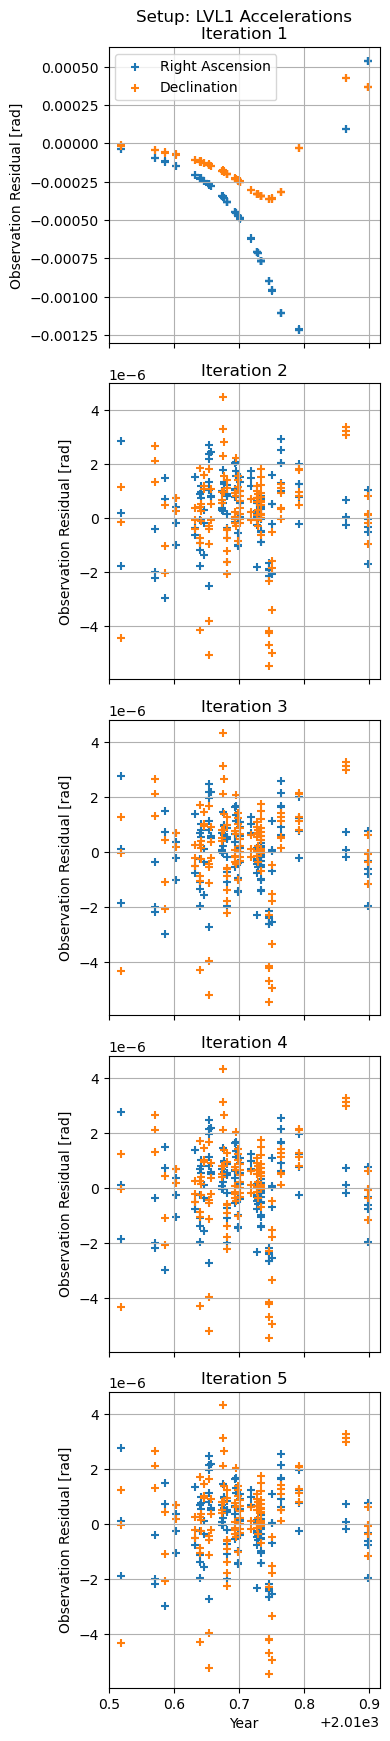

(<Figure size 1200x400 with 3 Axes>,
 array([<Axes: xlabel='Year', ylabel='X Cartesian Error [km]'>,
        <Axes: xlabel='Year', ylabel='Y Cartesian Error [km]'>,
        <Axes: xlabel='Year', ylabel='Z Cartesian Error [km]'>],
       dtype=object))

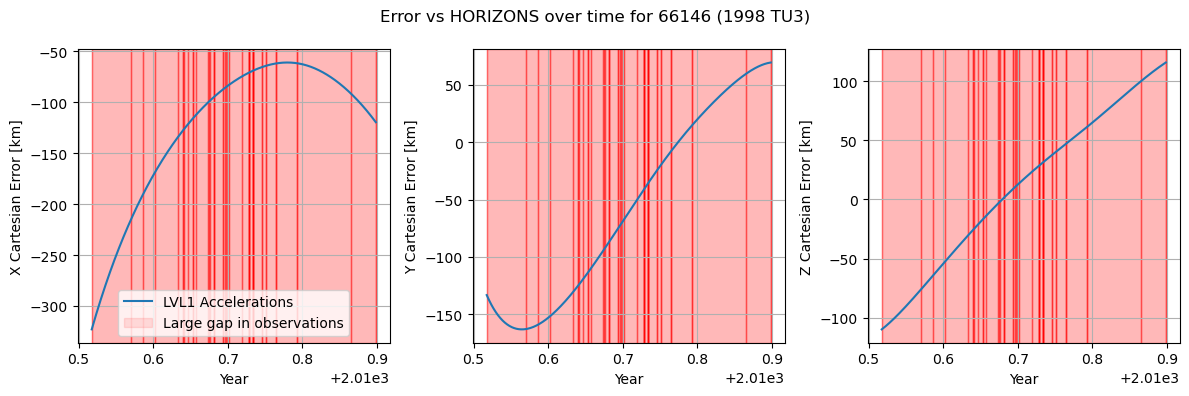

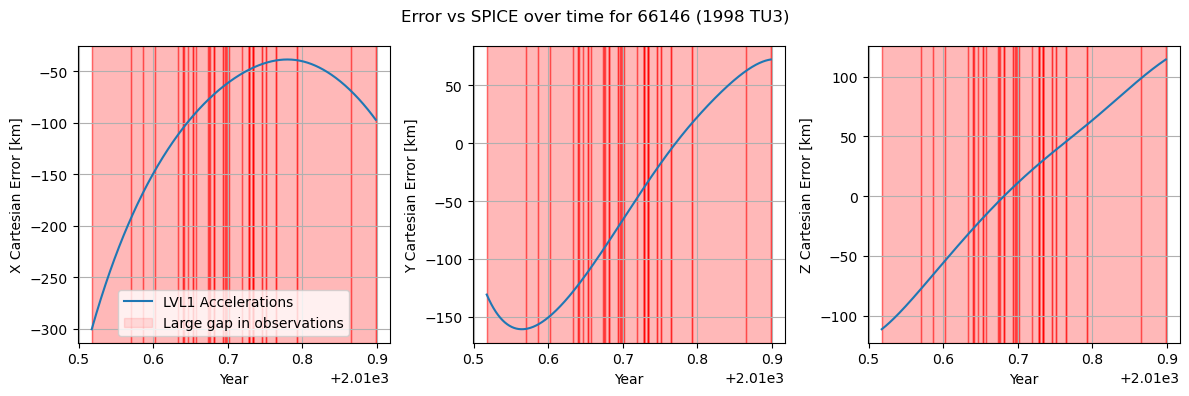

In [123]:
plot_residuals(setup_names, pod_output_set, observation_collection_set)
plot_cartesian(state_estimates_set, setup_names, observation_collection_set, "horizons")
plot_cartesian(state_estimates_set, setup_names, observation_collection_set, "spice")

In [124]:
# Correlation can be retrieved using the CovarianceAnalysisInput class:
covariance_input = estimation_analysis.CovarianceAnalysisInput(observation_collection)
covariance_output = estimator.compute_covariance(covariance_input)

correlations = covariance_output.correlations
estimated_param_names = ["x", "y", "z", "vx", "vy", "vz", "J2", "Beta-1"]

Calculating residuals and partials 256


In [125]:
# covariance_output.

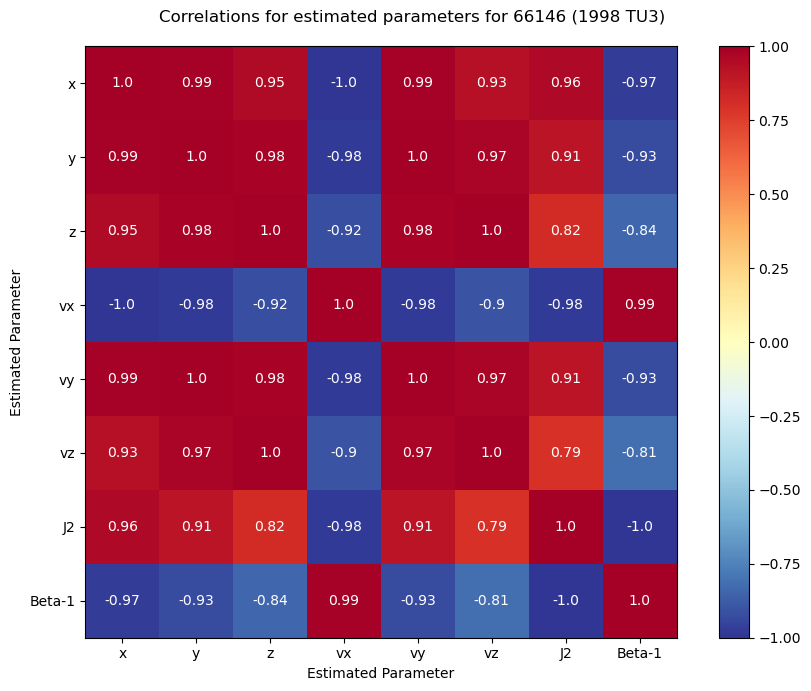

In [126]:
fig, ax = plt.subplots(1, 1, figsize=(9, 7))

im = ax.imshow(correlations, cmap=cm.RdYlBu_r, vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(estimated_param_names)), labels=estimated_param_names)
ax.set_yticks(np.arange(len(estimated_param_names)), labels=estimated_param_names)

# add numbers to each of the boxes
for i in range(len(estimated_param_names)):
    for j in range(len(estimated_param_names)):
        text = ax.text(
            j, i, round(correlations[i, j], 2), ha="center", va="center", color="w"
        )

cb = plt.colorbar(im)

ax.set_xlabel("Estimated Parameter")
ax.set_ylabel("Estimated Parameter")

fig.suptitle(f"Correlations for estimated parameters for {target_name}")

fig.set_tight_layout(True)

In [44]:
# The covariance matrix of TU3:
# I needed it as a picture in case the code died yes

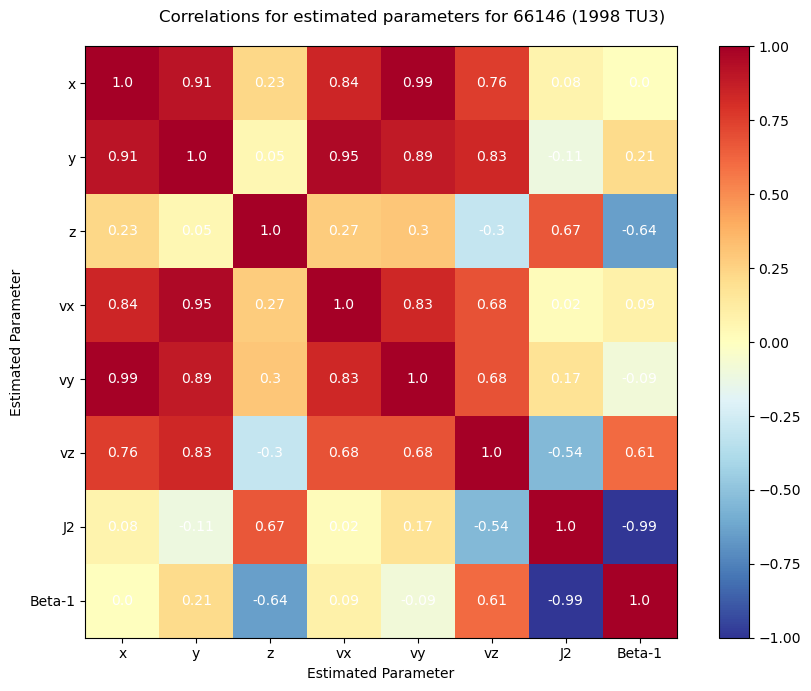